# Temperature Analysis

This notebook uses light cure data from LSST in order to estimate the temperature of an object.

The main way this is done is by fitting a black body curve to the flux measured across several filters. The results of this are plotted daily from data taken over a default rolling window of 3 days.

In addition temperature is also found using pairs of filters. This method is substantially worse at estimating temperature but it can be useful in seeing trends that might suggest that this might not be a black body source. More information on this method and its limitations can be seen in the pair analysis section.

This notebook provides a way to plot this data for a given object in the Pitt-Google brokers database. Several examples of this are plotted at the end of this notebook.

Some of this code mostly the pair analysis section is directly from or modified from lasair. Any code of this nature will be labeled as such in the markdown text above it and as a comment on the first line of the code block.

## Prerequisites
- Complete the [One-Time Setup](https://mwvgroup.github.io/pittgoogle-client/one-time-setup/index.html), specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the BigQuery API
     - You can skip the command-line tools

In [42]:
import pittgoogle
pgb_project = "pitt-alert-broker" # define the Pitt-Google Alert Broker's GCP project name
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

# makes matplotlib plots interactive
%matplotlib widget
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import numpy as np
import math

# for saving sql query results
import pickle
from pathlib import Path
import os

import mwdust
# Initialize the 2D SFD dust map
sfdMap = mwdust.SFD(filter='E(B-V)')

from astropy.coordinates import SkyCoord
from astropy.stats import sigma_clip

from itertools import compress

In [16]:
# The LSST bands, wavelength in microns from https://lsstcam.lsst.io/
WL = {'u': 0.3724, 'g': 0.4807, 'r': 0.6221, 'i': 0.7559, 'z': 0.8680, 'y': 0.9753}

From Lasiar Examples

These coefficients are for the extinction correction. 
For the g-filter, for example, an E(B-V) value of 0.5 
would increase the g magnitude number by 0.5*3.237 = 1.618 mags,
equivalently decrease the flux by a factor of 10^(1.618/2.5) = 4.43.

These colour corrections are from Table 6 of 
[Schlafly and Finkbeiner](https://iopscience.iop.org/article/10.1088/0004-637X/737/2/103) with RV=3.1

In [17]:
# From Lasiar Examples
# Multiplier for EBV for magnitude correction
EXTCOEF   = {'u': 4.145, 'g': 3.237, 'r': 2.273, 'i': 1.684, 'z': 1.323, 'y': 1.088}

### Blackbody spectrum

Modified from Lasiar Examples

This formula is "per Hertz" to match up with the definition of Jansky.
The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
In addition a scale factor is added which accounts for the flux being dependent on object size and distance from us.

In [18]:
# Modified from Lasiar Examples

def scaledBlackbody(wl, T, scale):
    hck = 14.387
    q = np.exp(hck/(wl*T))
    return scale * np.power(wl, -3.0) / (q - 1)

# dustFluxErr would be the same function as dustFlux since the dustFlux is effectively multiplying flux by a constant
def dustFlux(flux, band, ebv):
    return flux*math.pow(10, ebv*EXTCOEF[band]/2.5)

### Plot the light curve and temperatures

In [19]:
def plot(objID, objList, pairTemp, fitTemp, window):
    color = {'u':"#9900cc", 'g':"#3366ff", 'r':"#33cc33", 'i':"#ffcc00", 'z':"#ff0000", 'y':"#cc6600"}
    fig, (ax1, ax2, ax3) = plt.subplots(3, height_ratios=[2,1,2], figsize=(8,12), layout = 'constrained')
    
    # Plots the light curve of the object using o markers for non forced sources and x markers for forced sources
    # saves the output of the plot to make legend intractable
    bars1 = []
    fbars1 = []
    for band in color.keys():
        mask = (objList.band == band) & (~objList.isForced)
        fmask = (objList.band == band) & (objList.isForced)
        mjd = objList.loc[mask, 'midpointMjdTai']
        flux = objList.loc[mask, 'psfFlux']
        fluxErr = objList.loc[mask, 'psfFluxErr']
        
        fmjd = objList.loc[fmask, 'midpointMjdTai']
        fflux = objList.loc[fmask, 'psfFlux']
        ffluxErr = objList.loc[fmask, 'psfFluxErr']
                    
        # plot the sources
        bars1.append(ax1.errorbar(mjd, flux, yerr=fluxErr, marker='o', markeredgewidth=0,
                                  color=color[band], linestyle = 'None', label=band))
        
        # plot the forced sources
        fbars1.append(ax1.errorbar(fmjd, fflux, yerr=ffluxErr, marker='X', markeredgewidth=0,
                                   color=color[band], linestyle = 'None', label=f'forced {band}'))
        
    bars1 = bars1 + fbars1
    
    # Labels for light curve plot
    fig.suptitle(f'Lightcuve of {objID}')
    ax1.set_xlabel('MJD')
    ax1.set_ylabel('Flux (nJy)')
    leg1 = ax1.legend(handles=bars1, ncols=2, handlelength=0.5, handletextpad=0.5)

    # Plots the pair analysis results with each half of the point representing one of the filters used
    for i in range(len(pairTemp['temp'])):
        ax2.plot(pairTemp['mjd'][i], pairTemp['temp'][i],
                 marker = 'o', markeredgewidth=0, fillstyle='left',
                 markerfacecolor=color[pairTemp['filter1'][i]], markerfacecoloralt=color[pairTemp['filter2'][i]],
                 zorder=1)
    
    # plot the results of the fit temp function for each day
    ax2.errorbar(fitTemp['mjd'], fitTemp['temp'], yerr=fitTemp['tempErr'],
                 marker = '*', linestyle = 'None', color = 'black', zorder=10, label='fitTemp')
    
    # Link MJD in the temperature plot with that in the light curve plot
    ax2.sharex(ax1)

    # Labels for temperature plot
    ax2.set_title('Calculated Pair and Fit Temperature of ' + str(objID))
    ax2.set_xlabel("MJD")
    ax2.set_ylabel("Temperature (kK)")
    ax2.legend(handlelength=0.5, handletextpad=0.5)

    # Setup for the black body plot
    cmap = plt.colormaps['inferno']
    blackbodyColors = cmap(np.linspace(0, 1, len(fitTemp['temp'])))
    x = np.linspace(0, 1.5, 51)[1:]
    markers = ['o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'H', 'D', 'd', 'P', 'X']

    # Plots the fitted black body curve for each day and the points it was fit to
    bars3 = []
    lines3 = []
    for i in range(len(fitTemp['temp'])):
        bars3.append(ax3.errorbar(fitTemp['wavelengths'][i], fitTemp['fluxs'][i], yerr=fitTemp['fluxErrs'][i],
                                    marker = markers[i%len(markers)], markeredgewidth=0,
                                    linestyle = 'None', color = blackbodyColors[i],
                                    label = f'{fitTemp['temp'][i]:.2f} kK at {fitTemp['mjd'][i]}'))
        y = scaledBlackbody(x, fitTemp['temp'][i], fitTemp['scale'][i])
        line, = ax3.plot(x, y, color = blackbodyColors[i])
        lines3.append(line)

    # Link flux in the black body plot with that in the light curve plot
    ax3.sharey(ax1)

    # Labels for black body plot
    leg3 = fig.legend(handles=bars3, loc='outside lower center', ncols=5, mode='expand', handlelength=0.5, handletextpad=0.5) 
    ax3.set_title(f'Blackbody Fit for Each Night with Rolling Window of {window} Days')
    ax3.set_ylabel('Flux (nJy)')
    ax3.set_xlabel(r'Wavelength ($\mu$m)')

    # Let the curve go to the edge of the plot
    ax3.margins(x=0)

    # add labels for each band in the black body plot
    ax3.set_xticks(list(tick for tick in WL.values()), list(f'\n{tick}' for tick in WL.keys()), minor = True)

    # Make the lines inviable if clicked on in the legend. Adapted from https://matplotlib.org/stable/gallery/event_handling/legend_picking.html
    mapLegendToAx = {}  # Will map legend lines to original lines.
    pickRadius = 5  # Points (Pt). How close the click needs to be to trigger an event.

    # connect the legend to the line for each plot
    for legendLine, legendText, axBar in zip(leg1.legend_handles, leg1.get_texts(), bars1):
        legendLine.set_picker(pickRadius) # Enable picking on the legend line.
        legendText.set_picker(pickRadius) # Enable picking on the legend text.
        mapLegendToAx[legendLine] = {'plot': 1, 'bar': axBar, 'text': legendText}
        mapLegendToAx[legendText] = {'plot': 1, 'bar': axBar, 'text': legendText}

    for legendLine, legendText, axBar, axLine in zip(leg3.legend_handles, leg3.get_texts(), bars3, lines3):
        legendLine.set_picker(pickRadius) # Enable picking on the legend line.
        legendText.set_picker(pickRadius) # Enable picking on the legend text.
        mapLegendToAx[legendLine] = {'plot': 3, 'bar': axBar, 'line': axLine, 'text': legendText}
        mapLegendToAx[legendText] = {'plot': 3, 'bar': axBar, 'line': axLine, 'text': legendText}
    
    def on_pick(event):
        # On the pick event, find the original line corresponding to the legend
        # proxy line, and toggle its visibility.
        clickedArtist = event.artist

        # Do nothing if the source of the event is not a legend line.
        if clickedArtist not in mapLegendToAx:
            return
        
        clickedOn = mapLegendToAx[clickedArtist]
        # if shift clicked show the corresponding line and hide all others
        if event.mouseevent.key == 'shift':
            for key in mapLegendToAx:
                notClicked = mapLegendToAx[key]
                if clickedOn['plot'] == notClicked['plot']:
                    if notClicked['plot'] == 3:
                        notClicked['line'].set_visible(False)

                    notClicked['bar'][0].set_visible(False)
                    for bar in notClicked['bar'][1] + notClicked['bar'][2]:
                        bar.set_visible(False)

                    # Change the alpha on the text in the legend, so we can see what lines
                    # have been toggled.
                    notClicked['text'].set_alpha(0.2)
                    
            if clickedOn['plot'] == 3:
                clickedOn['line'].set_visible(True)

            clickedOn['bar'][0].set_visible(True)
            for bar in clickedOn['bar'][1] + clickedOn['bar'][2]:
                bar.set_visible(True)

            # Change the alpha on the text in the legend, so we can see what lines
            # have been toggled.
            clickedOn['text'].set_alpha(1)

        # if clicked toggle the corresponding line
        else:
            visible = not clickedOn['bar'][0].get_visible()

            if clickedOn['plot'] == 3:
                clickedOn['line'].set_visible(visible)

            clickedOn['bar'][0].set_visible(visible)
            for bar in clickedOn['bar'][1] + clickedOn['bar'][2]:
                bar.set_visible(visible)

            # Change the alpha on the text in the legend, so we can see what lines
            # have been toggled.            
            clickedOn['text'].set_alpha(1.0 if visible else 0.2)

        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', on_pick)
    plt.show()

## Fit Temperature
This method of finding temperature uses the fact that LSST revisits sites in multiple filters each night. This allows fitting a black body curve to the flux data. This results in a temperature and scaling factor for each night.

In [48]:
# A version of sigma_clip that returns the mean of selected values weighted by there errors
# and the error based on the std and how many points are returned
def weightedMean3Sigma(fluxs, fluxErrs, sqrtAvgCount):
    # get the masked list
    maskedFluxs = sigma_clip(fluxs, sigma=3, cenfunc='median')

    if maskedFluxs.count() == 0:
        return None, None
    
    # an error based on the std and how many points are returned
    error = np.ma.std(maskedFluxs) * (sqrtAvgCount/np.sqrt(maskedFluxs.count()))

    # if std = 0 for example if maskedFluxs only has one element or if all elements are the same
    # use the fluxErrs instead to keep the fit function happy
    error = error if error > 0 else np.average(list(compress(fluxErrs, ~maskedFluxs.mask))) * sqrtAvgCount

    return np.ma.average(maskedFluxs, weights=np.pow(fluxErrs, -2)), error

# Fit a black body curve to a set of fluxes taken from the list of sources on a given day and the following window-1 days
# This is done for each night in the dataset
def calculateFitTemp(objList, ebv, window):
    start = objList.midpointMjdTai[0]
    end = objList.midpointMjdTai.iloc[-1]

    output = {'temp': [], 'tempErr': [], 'scale': [], 'scaleErr': [], 'mjd': [],
              'wavelengths': [], 'fluxs': [], 'fluxErrs': []}
    
    i = 0
    start = 0
    # The addition of 0.3 to each time will alow data taken shortly before an integer MJD (8:00PM in Chile)
    # to be added to the rest of the data taken on the same night rather than to the previous night
    mjdOffset = 0.3
    for mjd in range(math.floor(start + mjdOffset), math.ceil(end + mjdOffset)):
        # For a given day find a list of the fluxes, fluxErrs, and bands within the given window
        flux = {key: [] for key in WL}
        fluxErr = {key: [] for key in WL}
        bands = set()
        i = start+1
        # loop through object list while the mjd is in the desired range
        while i < len(objList) and math.floor(objList.midpointMjdTai[i] + mjdOffset) <= mjd + window - 1:
            # set the place to start i for the next day
            if math.floor(objList.midpointMjdTai[i] + mjdOffset) == mjd:
                start = i
            band = objList.band[i]
            bands.add(band)
            flux[band].append(dustFlux(objList.psfFlux[i], band, ebv))
            fluxErr[band].append(dustFlux(objList.psfFluxErr[i], band, ebv))
            i+=1
        # once all fluxes, fluxErrs, and bands within the given window are found
        # ensure that three filters have been found, two works but gives inconstant results
        # otherwise dont try to fit for that day and move on to the next
        if len(bands) >= 3:
            fluxMean = []
            fluxStd = []
            wavelength = []

            # find a mean value for each filter with measurements excluding points more than 3 sigma from the median
            # and a std modified by a factor of sqrt(average count)/sqrt(count in this filter)
            # this modification should tell the fitting function to pay more attention to filters with more points
            sqrtAvgCount = np.sqrt(np.sum(list(map(len, flux))) / len(bands))
            for band in flux:
                if len(flux[band]) > 0:
                    fMean, fStd = weightedMean3Sigma(flux[band], fluxErr[band], sqrtAvgCount)
                    if fMean != None:
                        fluxMean.append(fMean)
                        fluxStd.append(fStd)
                        wavelength.append(WL[band])
            try:
                # fit the black body curve and record the results in addition to the points used in the fit
                fit = curve_fit(scaledBlackbody, wavelength, fluxMean, [12, 1], bounds=([0, -np.inf], [1000, np.inf]), sigma=fluxStd, absolute_sigma=True)
                output['temp'].append(fit[0][0])
                output['scale'].append(fit[0][1])
                
                error = np.sqrt(np.diag(fit[1]))
                output['tempErr'].append(error[0])
                output['scaleErr'].append(error[1])

                output['mjd'].append(mjd)
                
                output['wavelengths'].append(wavelength)
                output['fluxs'].append(fluxMean)
                output['fluxErrs'].append(fluxStd)
            except:
                print(f'Failed fit with\nWavelengths: {wavelength}\nFluxes: {fluxMean}\nFlux errors: {fluxStd}')
              
    return output

## Calculate the temperature from pairs of filters taken in a short window
This is not a great method since it gives extremely noisy results and often give significantly different results based on the specific pair of filters used. It is mainly included here to contrast with the fitted temperature which gives significantly better results but operates on a largely similar concept. This function is an improved version of one shown in Lasiar's Examples.

### Blackbody spectrum

From Lasiar Examples

This formula is "per Hertz" to match up with the definition of Jansky.
The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
There is also the derivative with respect to T so that we can do a Newton solver.
The commented out code shows that the derivative formula is numerically correct.

In [21]:
# From Lasiar Examples

def blackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) /(q - 1)

def dblackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) * (hck/(wl*T*T)) * q/((q-1)*(q-1))

### Newton solver
From Lasiar Examples

Given a flux ratio `fluxrat` and two wavelengths `wl1` and `wl2`, we want to solve for the temperature `T`:
```
blackbody(wl1, T)/blackbody(wl2, T) = fluxrat

--> blackbody(wl1, T) - fluxrat* blackbody(wl2, T) = 0
```
However the flux ratio is first modified because of extinction, as the different 
wavelengths are extincted differently. See `EXTCOEF` above. First we make a magnitude change, 
then convert that to a multiplier on the flux ratio.

In [22]:
# From Lasiar Examples

def solveForTemperature(fluxrat, i1, i2, ebv=0):

    # if i1>i2:
    #     (i1,i2)=(i2,i1)
    #     fluxrat = 1/fluxrat
    
    # modify fluxrat for extinction
    mag_corr = ebv*(EXTCOEF[i1] - EXTCOEF[i2])
    fluxrat_corr = fluxrat*math.pow(10, mag_corr/2.5)
    
    T = 12  # guess 12,000 kelvin
    wl1 = WL[i1]
    wl2 = WL[i2]
    for i in range(50):
        try:
            fr  =  blackbody(wl1, T) - fluxrat_corr* blackbody(wl2, T)
            dfr = dblackbody(wl1, T) - fluxrat_corr*dblackbody(wl2, T)
        except:
            return None
        if dfr == 0:
            print('dfr = 0:', fluxrat, i1, i2, ebv)
            return None
        dT = fr/dfr
        T = T - dT
        if abs(dT) < 0.001: return T # convergence
            
        if T < 0: return None  # not interested in negative temperatures
    return None

### Pair Temperature

Inspired by Lasair Examples

This method of finding temperature uses the fact that LSST revisits sites in multiple filters in a short time window. This allows a ratio of fluxes to be found between pairs of filters allowing the Newtonian solver above to estimate a temperature.

In [23]:
# Inspired by Lasiar Examples

def calculatePairTemp(objList, ebv):
    output = {'temp': [], 'mjd': [], 'filter1': [], 'filter2': []}

    # average points of the same filter in a row
    condensedObjList = []
    fluxSum = objList.psfFlux[0]
    MJDSum = objList.midpointMjdTai[0]
    MJDStart = objList.midpointMjdTai[0]
    count = 1

    for i in range(1, len(objList)):
        if objList.band[i] == objList.band[i-1] and objList.midpointMjdTai[i] - objList.midpointMjdTai[i-1] < 0.04:
            fluxSum += objList.psfFlux[i]
            MJDSum += objList.midpointMjdTai[i]
            count += 1
        else:
            condensedObjList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count,
                                     'startMJD': MJDStart, 'endMJD': objList.midpointMjdTai[i-1],
                                     'band': objList.band[i-1]})
            fluxSum = objList.psfFlux[i]
            MJDSum = objList.midpointMjdTai[i]
            MJDStart = objList.midpointMjdTai[i]
            count = 1
    condensedObjList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count,
                             'startMJD': MJDStart, 'endMJD': objList.midpointMjdTai[i-1],
                             'band': objList.band[i-1]})

    # calculate temperature for all pairs of points that are close enough together regardless of adjacency
    for i in range(0, len(condensedObjList) - 1):
        s1 = condensedObjList[i]
        s2 = condensedObjList[i+1]
        ahead = 1
        while s2['startMJD'] - s1['endMJD'] < 0.04:
            if s1['band'] != s2['band']:
                s = solveForTemperature(s1['avgFlux']/s2['avgFlux'], s1['band'], s2['band'], ebv)
                if s:
                    output['temp'].append(s)
                    output['mjd'].append((s2['startMJD'] + s1['endMJD'])/2)
                    output['filter1'].append(s1['band'])
                    output['filter2'].append(s2['band'])
            ahead+=1
            if i+ahead < len(condensedObjList):
                s2 = condensedObjList[i+ahead]
            else:
                break

    return output

## Plot Temperature
plotTemp plots the light curve of a given object in addition to the calculated pair temperature for each pair of filters and the fitted temperature for each night with observations in different bands.

In [58]:
def getObjList(diaObjectId, useScience):
    if useScience:
        scienceOrPsf = 'science'
    else:
        scienceOrPsf = 'psf'

    # Find the flux, flux error, mjd, and band for each source of the given object
    # Get this from the most recent alert about the object
    # All of this information is in the most resent alert so it could be run on an incoming alert stream
    sqlObjectQuery = f"""
    WITH latest_alert AS (
        SELECT
        alerts.diaObject.diaObjectId,
        alerts.diaSource,
        alerts.prvDiaSources,
        alerts.prvDiaForcedSources
        FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        UNION ALL

        SELECT
        alerts.diaObject.diaObjectId,
        alerts.diaSource,
        alerts.prvDiaSources,
        alerts.prvDiaForcedSources
        FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        ORDER BY diaSource.midpointMjdTai DESC
        LIMIT 1
    )

    SELECT
    diaSource.midpointMjdTai,
    diaSource.{scienceOrPsf}Flux as psfFlux,
    diaSource.{scienceOrPsf}FluxErr as psfFluxErr,
    diaSource.reliability,
    diaSource.band,
    FALSE AS isForced
    FROM latest_alert

    UNION ALL

    SELECT
    prv.midpointMjdTai,
    prv.{scienceOrPsf}Flux as psfFlux,
    prv.{scienceOrPsf}FluxErr as psfFluxErr,
    prv.reliability,
    prv.band,
    FALSE AS isForced
    FROM latest_alert,
    UNNEST(prvDiaSources) AS prv

    UNION ALL

    SELECT
    prvforced.midpointMjdTai,
    prvforced.{scienceOrPsf}Flux as psfFlux,
    prvforced.{scienceOrPsf}FluxErr as psfFluxErr,
    -1 AS reliability,
    prvforced.band,
    TRUE AS isForced
    FROM latest_alert,
    UNNEST(prvDiaForcedSources) AS prvforced

    ORDER BY midpointMjdTai
    """

    bqclient.query(query=sqlObjectQuery, dry_run=True)
    objList = bqclient.query(query=sqlObjectQuery)

    # handle rows with null values
    objList.dropna(subset=['midpointMjdTai', 'psfFlux', 'band'], inplace = True)
    objList.fillna(value={'psfFluxErr': np.nanmax(objList.psfFluxErr, initial=0)}, inplace = True)
    objList.reset_index(drop=True, inplace=True)
    return objList

def getGaiaMatch(diaObjectId):
    sqlGaiaMatchQuery = f"""
    WITH latest_alert AS (
        SELECT
        alerts.diaObject.ra,
        alerts.diaObject.dec,
        FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        UNION ALL

        SELECT
        alerts.diaObject.ra,
        alerts.diaObject.dec,
        FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
        WHERE alerts.diaObject.diaObjectId = {diaObjectId}

        LIMIT 1
    ),

    xmatch_gaia AS (
        SELECT
        'agn' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.agn` as gaia

        UNION ALL

        SELECT
        'cepheid' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.cepheid` as gaia

        UNION ALL

        SELECT
        'long_period_variable' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.long_period_variable` as gaia

        UNION ALL

        SELECT
        'ms_oscillator' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.ms_oscillator` as gaia

        UNION ALL

        SELECT
        'rotation_modulation' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.rotation_modulation` as gaia

        UNION ALL

        SELECT
        'rrlyrae' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.rrlyrae` as gaia

        UNION ALL

        SELECT
        'short_timescale' AS type,
        gaia.ra,
        gaia.dec,
        gaia.teff_gspphot,
        gaia.teff_gspphot_lower,
        gaia.teff_gspphot_upper,
        FROM `pitt-alert-broker.xmatch_gaia.short_timescale` as gaia
    )

    SELECT
        a.*,
        g.*,
        SQRT(
            POW((g.ra - a.ra) * 3.1415 / 180.0 * COS(a.dec * 3.1415 / 180.0), 2) +
            POW((g.dec - a.dec) * 3.1415 / 180.0, 2)
        ) * 180 / 3.1415 * 3600.0 AS separation_arcsec
    FROM latest_alert a
    LEFT JOIN xmatch_gaia g ON
        ABS(g.ra - a.ra) < 0.01
        AND ABS(g.dec - a.dec) < 0.01
    ORDER BY separation_arcsec
    LIMIT 1;
    """

    bqclient.query(query=sqlGaiaMatchQuery, dry_run=True)
    return bqclient.query(query=sqlGaiaMatchQuery)

In [60]:
def plotTemp(diaObjectId, save=False, update=True, useScience=False, window=3):
    try:
        file_path = Path(f'{os.getenv('OBJECT_CACHE_DIR')}example-objects/{'science' if useScience else 'psf'}object{diaObjectId}.pkl')
    except:
        if (not update) or save:
            raise
        else:
            # ignore the error if we are not using the file path
            pass

    # if it exists and we dont want to update use cashed object list load a saved file
    if (not update) and file_path.is_file():
        with open(file_path, 'rb') as inf: 
            (objList, gaia) = pickle.load(inf)
    else:
        objList = getObjList(diaObjectId, useScience)
        
        gaia = getGaiaMatch(diaObjectId)
        
        if save == True:
            with open(file_path, 'wb') as outf:
                pickle.dump((objList, gaia), outf)

    c = SkyCoord(gaia.ra[0], gaia.dec[0], unit="deg", frame='icrs')

    # The third argument is a distance
    # It seems to have no affect since SFD is 2D not 3D but it is a required field
    # I pass a large distance (100 kpc) in case it matters at some locations
    ebv = sfdMap(c.galactic.l.deg, c.galactic.b.deg, 100)[0]

    print('Object Id:', diaObjectId)

    # print(objList)
    # objList.psfFlux -= np.min(objList.psfFlux)
    
    if gaia.type[0] != None:
        print(gaia.to_markdown())

    # remove outliers and report them
    # this was added since every once an a while there are points with fluxes around -60000 nJy
    maskedFluxs = sigma_clip(objList.psfFlux, sigma=10, cenfunc='median')
    indicesToRemove = np.flatnonzero(maskedFluxs.mask)
    if len(indicesToRemove) > 0:
        print('Removed outliers:\n' + objList.loc[indicesToRemove].to_markdown())
        objList.drop(indicesToRemove, inplace=True)
        objList.reset_index(drop=True, inplace=True)

    # get temperature estimates
    pairTemp = calculatePairTemp(objList, ebv)
    fitTemp = calculateFitTemp(objList, ebv, window)

    # report some statistics about the fitted temperatures
    mean = weightedMean3Sigma(fitTemp['temp'], fitTemp['tempErr'], np.sqrt(len(fitTemp['temp'])))
    print(f'Fit Temperature Weighted 3 Sigma Mean: {mean[0]} kK')
    print(f'Fit Temperature Standard Deviation: {mean[1]} kK')
    print(f'Fit Temperature Median: {np.median(fitTemp['temp'])} kK')

    plot(diaObjectId, objList, pairTemp, fitTemp, window)

## Examples
- The plots can be zoomed, paned, saved, etc. using the buttons on the top left
- Curves can be disabled or reenabled by clicking on them in the legend
- All curves but the one clicked on can be disabled by shift clicking

### Example 1 object 170028526486945858
plotTemp takes an objectID and get the required information from the pitt-google broker. It can be configured to save the result of the query and use it for future runs.

This query will process 61,483,069,149 bytes
This query will process 366,949,592 bytes
Object Id: 170028526486945858
|    |      ra |     dec | type   |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|--------:|:-------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 186.189 | 6.58912 | agn    | 186.137 | 6.62531 |        6740.52 |              6688.36 |              6792.89 |             225.617 |
Fit Temperature Weighted 3 Sigma Mean: 9.866151239602113 kK
Fit Temperature Standard Deviation: 1.1683631881237813 kK
Fit Temperature Median: 9.96564845905898 kK


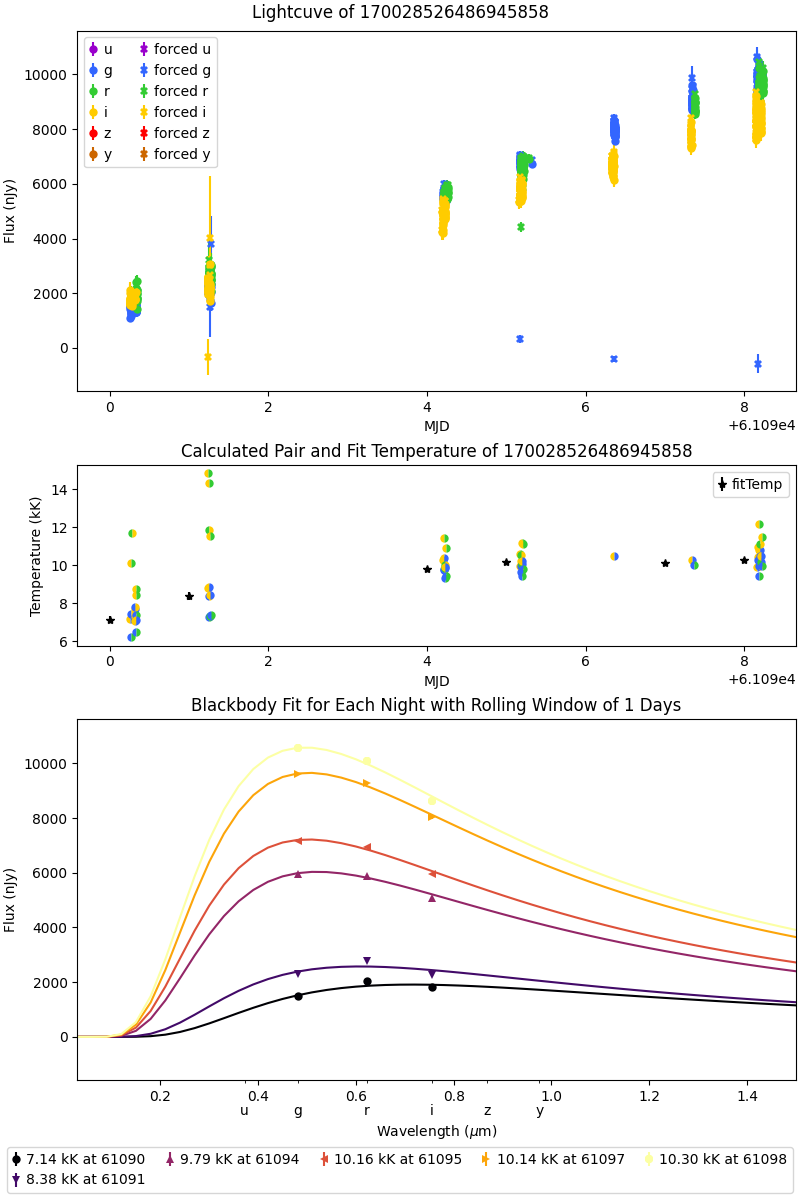

In [30]:
diaObjectId = 170028526486945858
plotTemp(diaObjectId, save=True, update=False, window=1)

### Example 2 object 313853517401423939

Object Id: 313853517401423939
Removed outliers:
|      |        diaObjectId |      ra |     dec |   midpointMjdTai |   psfFlux |   psfFluxErr | band   | isForced   |
|-----:|-------------------:|--------:|--------:|-----------------:|----------:|-------------:|:-------|:-----------|
| 1538 | 313853517401423939 | 149.377 | 3.11599 |            61189 |    -13786 |      426.572 | g      | True       |
Fit Temperature Weighted 3 Sigma Mean: 7.9507290463743105 kK
Fit Temperature Standard Deviation: 0.7917949349644525 kK
Fit Temperature Median: 8.02275121827196 kK


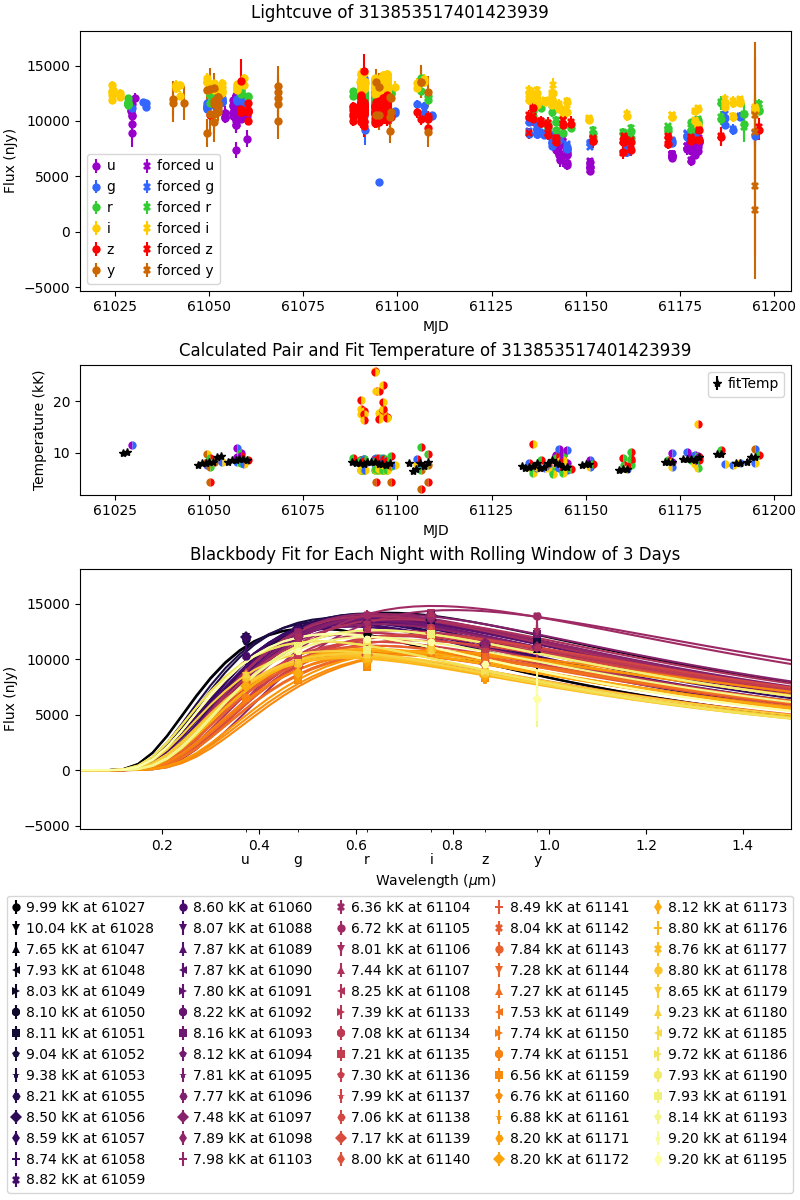

In [35]:
diaObjectId = 313853517401423939
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 3 object 313928194477522960

This query will process 61,483,069,149 bytes
This query will process 366,949,592 bytes
Object Id: 313928194477522960
Fit Temperature Weighted 3 Sigma Mean: 3.9411341925174246 kK
Fit Temperature Standard Deviation: 1.6131078649229589 kK
Fit Temperature Median: 6.3595225686828964 kK


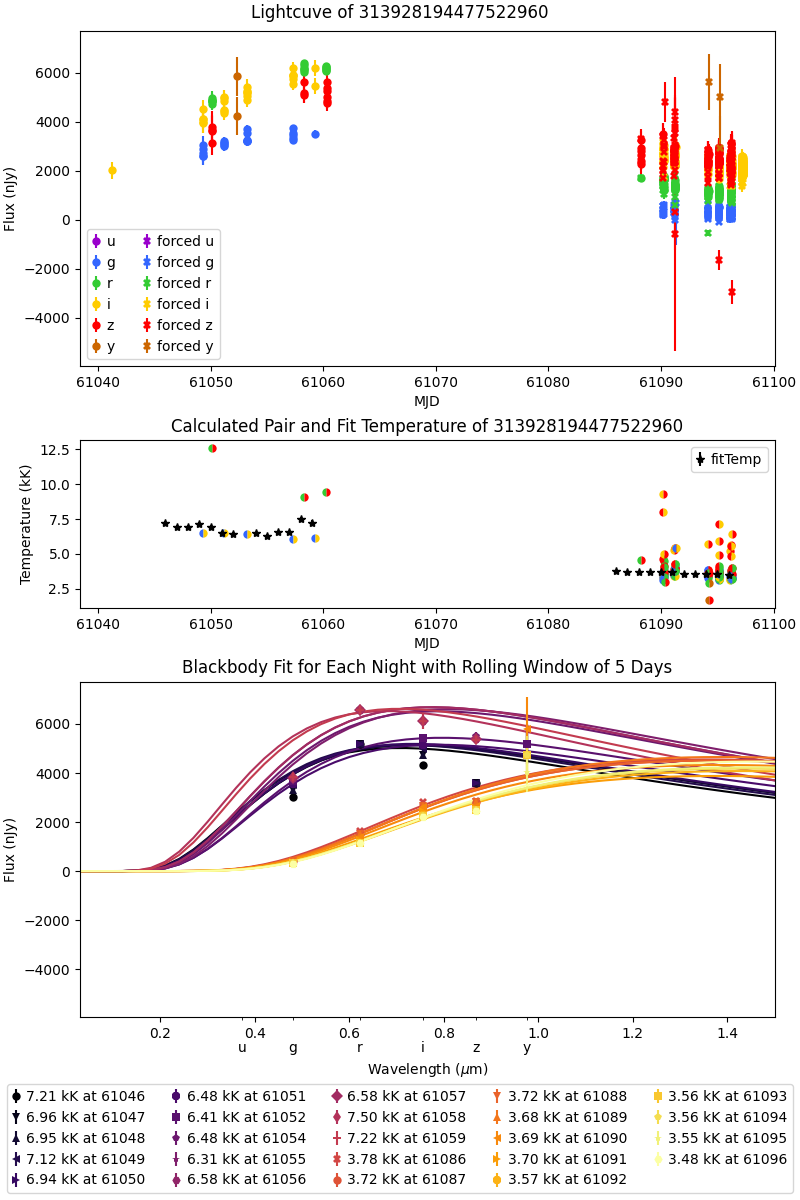

In [62]:
diaObjectId = 313928194477522960
plotTemp(diaObjectId, save=True, update=False, window=5)

### Example 4 object 313853517416628317 compared to GAIA
Gaia DR3 3848359966449030272

Teff    7070 [7039, 7110]	K

This query will process 61,483,069,149 bytes
This query will process 366,949,592 bytes
Object Id: 313853517416628317
|    |      ra |     dec | type   |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|--------:|:-------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 149.023 | 2.88108 | agn    | 149.023 | 2.88108 |        7069.84 |               7038.9 |              7109.75 |           0.0337231 |
Failed fit with
Wavelengths: [0.4807, 0.7559, 0.9753]
Fluxes: [np.float64(8155.392469146013), np.float64(9753.120959866597), np.float64(9667.753846466485)]
Flux errors: [np.float64(74.9096736897878), np.float64(798.4436285300886), np.float64(2753.0916136016313)]
Fit Temperature Weighted 3 Sigma Mean: 7.389750881268355 kK
Fit Temperature Standard Deviation: 1.6925940950661473 kK
Fit Temperature Median: 8.814342198896021 kK


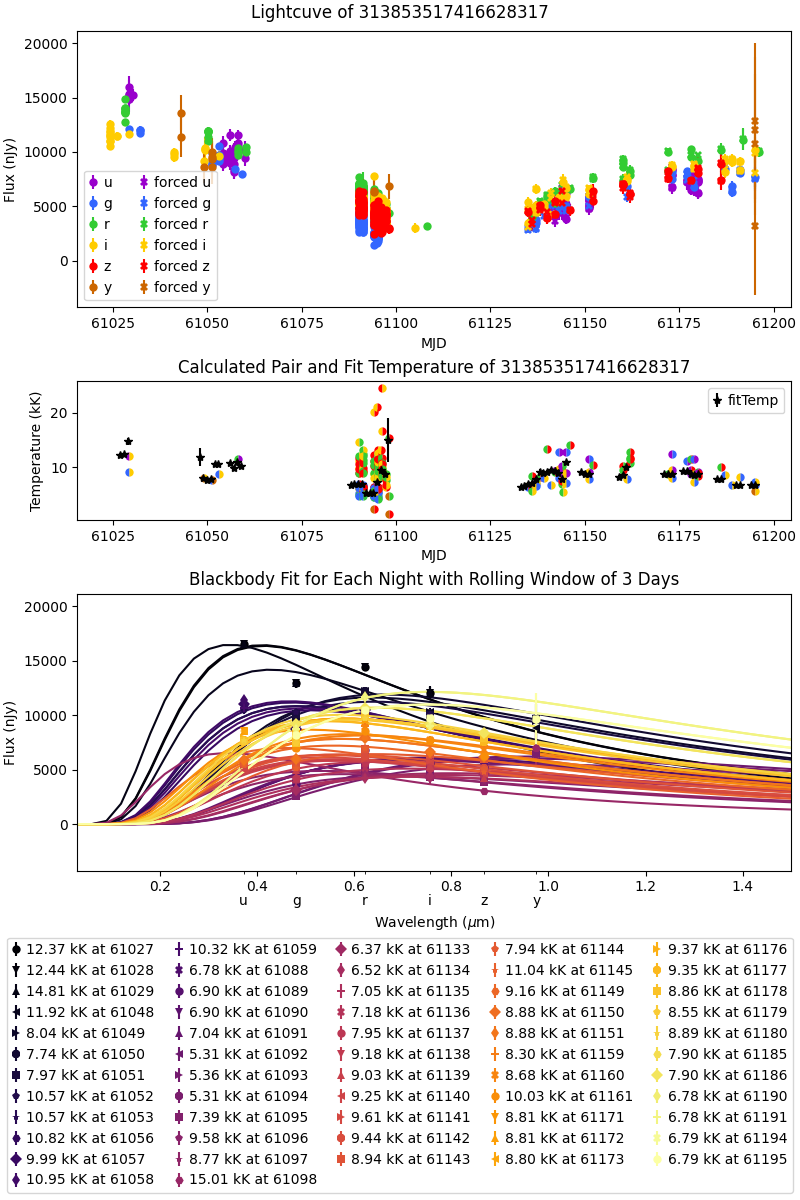

In [61]:
diaObjectId = 313853517416628317
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 5 object 313875415093477395 compared to GAIA
Gaia DR3 3836000768557705344

Teff	6132 [6108, 6153]	K

This query will process 61,483,069,149 bytes
This query will process 366,949,592 bytes
Object Id: 313875415093477395
Removed outliers:
|     |   midpointMjdTai |   psfFlux |   psfFluxErr |   reliability | band   | isForced   |
|----:|-----------------:|----------:|-------------:|--------------:|:-------|:-----------|
| 839 |          61137.2 |  -35450.3 |      433.729 |            -1 | i      | True       |
| 964 |          61173   |  -69308.3 |      287.353 |            -1 | i      | True       |
Fit Temperature Weighted 3 Sigma Mean: 9.884144945418152 kK
Fit Temperature Standard Deviation: 2.0937331975112716 kK
Fit Temperature Median: 10.670509487338075 kK


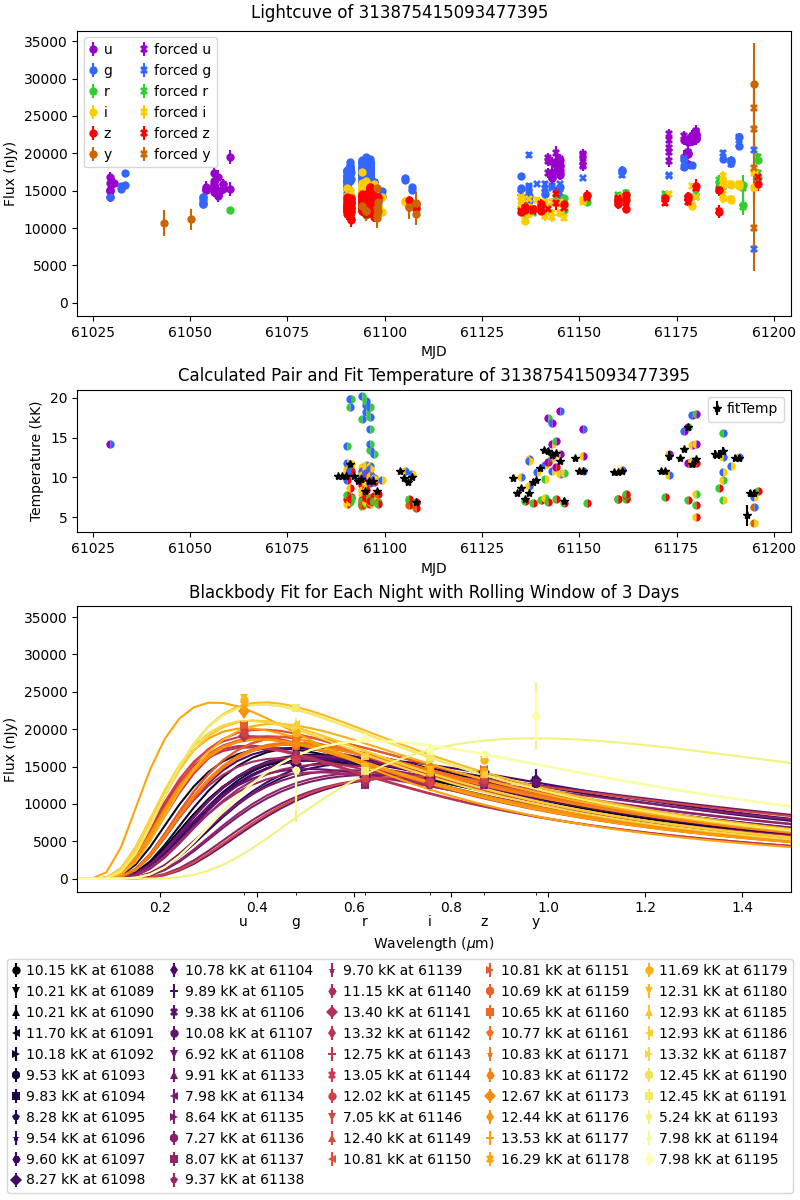

In [63]:
diaObjectId = 313875415093477395
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 6 object 313875415068311567 compared to GAIA
Gaia DR3 3836290318072886656

Teff	6233 [6196, 6263]	K

This query will process 61,483,069,149 bytes
This query will process 366,949,592 bytes
Object Id: 313875415068311567
|    |      ra |     dec | type   |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|--------:|:-------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 150.054 | 2.58968 | agn    | 150.054 | 2.58967 |        6232.76 |              6195.78 |              6263.01 |           0.0332644 |
Failed fit with
Wavelengths: [0.4807, 0.7559, 0.9753]
Fluxes: [np.float64(93378.83694230615), np.float64(120674.7951685957), np.float64(115408.61686644306)]
Flux errors: [np.float64(9.86267593143566), np.float64(583.0423139779667), np.float64(3294.265271069514)]
Failed fit with
Wavelengths: [0.4807, 0.6221, 0.7559, 0.9753]
Fluxes: [np.float64(93378.83694230615), np.float64(104381.7857474113), np.float64(120674.7951685957), np.float64(115408.61686644306)]
F

C:\Users\wagnernb\AppData\Local\Temp\ipykernel_21224\2563073931.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2, ax3) = plt.subplots(3, height_ratios=[2,1,2], figsize=(8,12), layout = 'constrained')


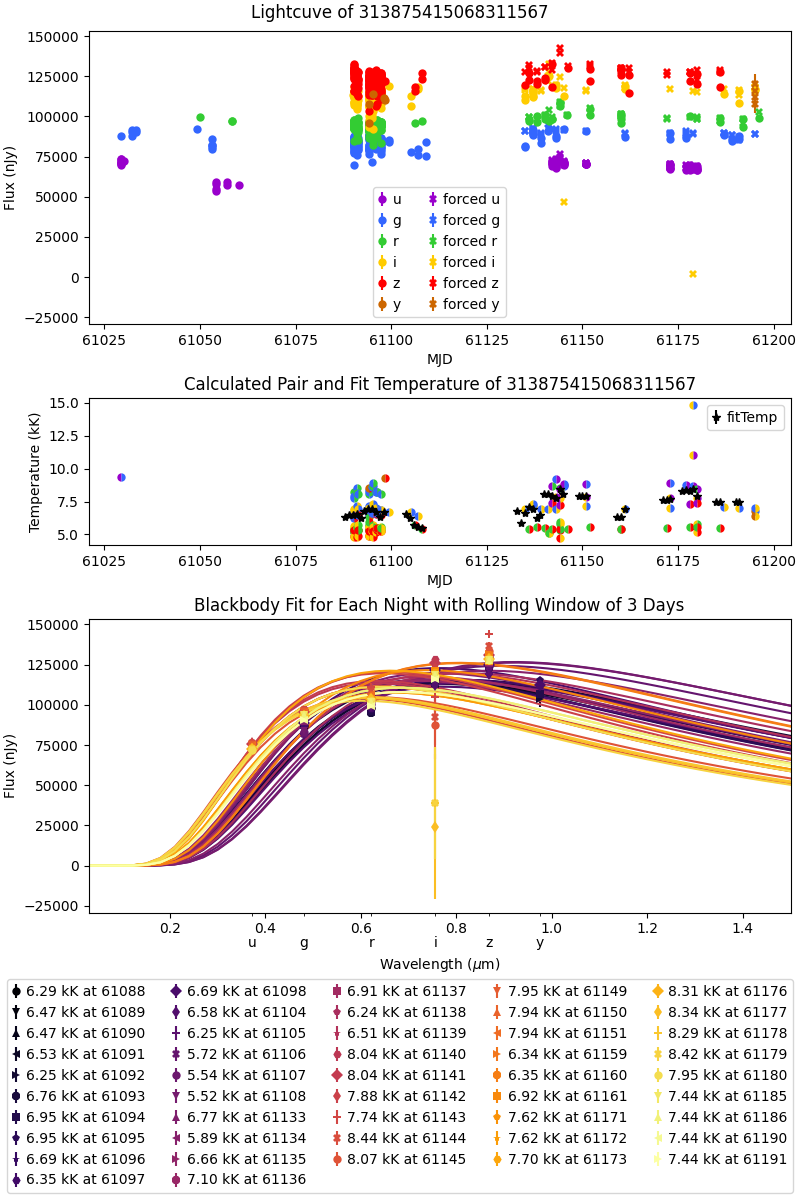

In [65]:
diaObjectId = 313875415068311567
plotTemp(diaObjectId, save=True, update=False, useScience=True, window=3)

### Example 7 object 313976545432567829 compared to GAIA

Object Id: 313976545432567829
|    |      ra |    dec | type    |    ra_1 |   dec_1 |   teff_gspphot |   teff_gspphot_lower |   teff_gspphot_upper |   separation_arcsec |
|---:|--------:|-------:|:--------|--------:|--------:|---------------:|---------------------:|---------------------:|--------------------:|
|  0 | 150.527 | 1.3757 | rrlyrae | 150.527 | 1.37571 |        6436.68 |              6370.28 |              6490.71 |           0.0465239 |
Failed fit with
Wavelengths: [0.4807, 0.7559, 0.9753]
Fluxes: [np.float64(743371.5407924177), np.float64(942334.0517679065), np.float64(1012269.497473666)]
Flux errors: [np.float64(3621.0055543816998), np.float64(31418.25410108146), np.float64(122112.83258812861)]
Failed fit with
Wavelengths: [0.4807, 0.7559, 0.868, 0.9753]
Fluxes: [np.float64(854772.4898453045), np.float64(1158157.101421986), np.float64(1367628.0273651902), np.float64(1318441.942757652)]
Flux errors: [np.float64(142931.5834315255), np.float64(78109.63395763688), np.float64(

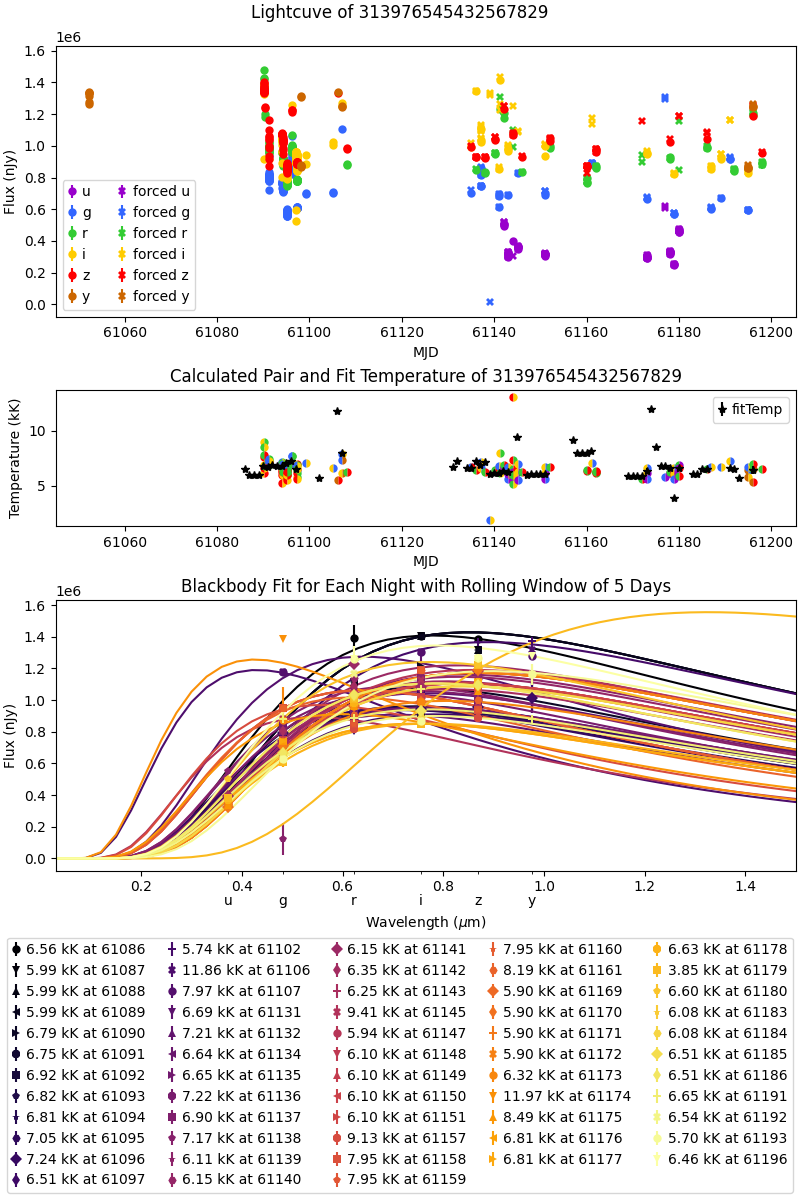

In [54]:
diaObjectId = 313976545432567829
plotTemp(diaObjectId, save=True, update=False, useScience=True, window=5)

In [26]:
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

sqlGaiaMatchQuery = f"""
WITH latest_alert AS (
    SELECT DISTINCT
    alerts.diaObject.diaObjectId,
    alerts.diaObject.nDiaSources,
    alerts.diaObject.ra,
    alerts.diaObject.dec,
    FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
    WHERE alerts.diaObject.nDiaSources > 100

    UNION ALL

    SELECT DISTINCT
    alerts.diaObject.diaObjectId,
    alerts.diaObject.nDiaSources,
    alerts.diaObject.ra,
    alerts.diaObject.dec,
    FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
    WHERE alerts.diaObject.nDiaSources > 100

    LIMIT 1000
),

xmatch_gaia AS (
    SELECT
    'cepheid' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.cepheid` as gaia

    UNION ALL

    SELECT
    'rrlyrae' AS type,
    gaia.ra,
    gaia.dec,
    gaia.teff_gspphot,
    gaia.teff_gspphot_lower,
    gaia.teff_gspphot_upper,
    FROM `pitt-alert-broker.xmatch_gaia.rrlyrae` as gaia
)

SELECT
    a.*,
    g.*,
    SQRT(
        POW((g.ra - a.ra) * 3.1415 / 180.0 * COS(a.dec * 3.1415 / 180.0), 2) +
        POW((g.dec - a.dec) * 3.1415 / 180.0, 2)
    ) * 180 / 3.1415 * 3600.0 AS separation_arcsec
FROM latest_alert a
JOIN xmatch_gaia g ON
    ABS(g.ra - a.ra) < 0.01
    AND ABS(g.dec - a.dec) < 0.01
"""

bqclient.query(query=sqlGaiaMatchQuery, dry_run=True)
gaia = bqclient.query(query=sqlGaiaMatchQuery)
gaia

This query will process 355,491,608 bytes


,diaObjectId,nDiaSources,ra,dec,type,ra_1,dec_1,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,separation_arcsec
0,313976545432567829,697,150.527283,1.375699,rrlyrae,150.527285,1.375712,6436.6800,6370.2820,6490.7085,0.046531
1,313888627074007083,368,149.136921,1.284973,rrlyrae,149.136933,1.284986,6858.6763,6702.3145,6949.3164,0.062178
2,313936986529333309,794,150.124522,0.877581,rrlyrae,150.124522,0.877592,7129.9966,7098.9310,7159.9760,0.040157
3,313994140600762399,362,150.228870,1.394702,rrlyrae,150.228886,1.394713,7843.9976,7599.2407,8130.7256,0.071326
4,313936986529333309,794,150.124522,0.877581,rrlyrae,150.124522,0.877592,7129.9966,7098.9310,7159.9760,0.040394
5,313994140600762399,352,150.228870,1.394702,rrlyrae,150.228886,1.394713,7843.9976,7599.2407,8130.7256,0.072032
6,313893021775560722,683,150.170660,1.368241,rrlyrae,150.170669,1.368240,NaN,NaN,NaN,0.033394
7,313994140600762399,372,150.228870,1.394701,rrlyrae,150.228886,1.394713,7843.9976,7599.2407,8130.7256,0.071540
8,313967766913679434,374,150.648605,3.006490,rrlyrae,150.648599,3.006504,5745.8286,5707.9260,5792.6460,0.054798
9,314003014011584569,210,150.651766,3.002574,rrlyrae,150.648599,3.006504,5745.8286,5707.9260,5792.6460,18.159678


In [97]:
import pandas as pd
pd.set_option('display.max_rows', 500)
alerts_tbl = pittgoogle.bigquery.Table(name="agn", dataset="xmatch_gaia", projectid=pgb_project)
alerts_tbl.schema

,name,type,mode
0,solution_id_var,INTEGER,NULLABLE
1,source_id,INTEGER,NULLABLE
2,fractional_variability_g,FLOAT,NULLABLE
3,structure_function_index,FLOAT,NULLABLE
4,structure_function_index_scatter,FLOAT,NULLABLE
5,qso_variability,FLOAT,NULLABLE
6,non_qso_variability,FLOAT,NULLABLE
7,solution_id_gaia,INTEGER,NULLABLE
8,designation,STRING,NULLABLE
9,random_index,INTEGER,NULLABLE
